# Cuaderno 03: Evaluación de Modelos
**Objetivo:** Evaluar el rendimiento de los modelos supervisados previamente entrenados. Utilizaremos el set de prueba (test set) y técnicas de Validación Cruzada (Cross-Validation) para asegurar que nuestras métricas sean robustas y representativas del desempeño real del modelo en producción.



*1. Carga de Modelos y Datos Serializados*
Cargamos los archivos `.pkl` que generamos en el Cuaderno 02. Esto nos permite evaluar los modelos sin necesidad de volver a entrenarlos, asegurando la consistencia de los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import joblib

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Cargando modelos y datos desde el disco...")

# Carga de modelos
pipeline_lr = joblib.load('../models/trained_models/pipeline_lr.pkl')
pipeline_rf = joblib.load('../models/trained_models/pipeline_rf.pkl')

# Carga de datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = joblib.load('../data/train_test_data.pkl')

print("¡Carga completada exitosamente!")

Cargando modelos y datos desde el disco...
¡Carga completada exitosamente!


*2. Métricas de Error en el Set de Prueba*
Calculamos las métricas fundamentales para entender la magnitud del error en nuestras predicciones de precios:
* **MAE (Error Absoluto Medio):** Promedio del error en dólares.
* **RMSE (Raíz del Error Cuadrático Medio):** Penaliza errores grandes.
* **R-cuadrado (R2):** Porcentaje de la varianza explicada por el modelo.

In [2]:
# Generar predicciones
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# Función para organizar resultados
def obtener_resumen_metricas(y_true, y_pred, nombre):
    return {
        'Modelo': nombre,
        'MAE (USD)': mean_absolute_error(y_true, y_pred),
        'RMSE (USD)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R-cuadrado': r2_score(y_true, y_pred)
    }

# Crear tabla comparativa
df_resumen = pd.DataFrame([
    obtener_resumen_metricas(y_test, y_pred_lr, 'Regresión Lineal'),
    obtener_resumen_metricas(y_test, y_pred_rf, 'Random Forest')
])

pd.options.display.float_format = '{:,.2f}'.format
display(df_resumen)

,Modelo,MAE (USD),RMSE (USD),R-cuadrado
0,Regresión Lineal,"432,298.32","653,810.50",0.35
1,Random Forest,"238,126.73","458,322.13",0.68


*3. Validación Cruzada Robusta (K-Fold CV)*

Para evitar que el azar en la división de los datos afecte nuestras conclusiones, aplicamos Validación Cruzada con 5 particiones (K=5). Esto nos da una visión más realista del error esperado.

In [3]:
print("Ejecutando Validación Cruzada (esto usa el set de entrenamiento)...")

# CV para Regresión Lineal
cv_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
mae_cv_lr = -cv_lr.mean()

# CV para Random Forest
cv_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
mae_cv_rf = -cv_rf.mean()

print(f"MAE Promedio (CV) - Regresión Lineal: ${mae_cv_lr:,.2f}")
print(f"MAE Promedio (CV) - Random Forest:  ${mae_cv_rf:,.2f}")

Ejecutando Validación Cruzada (esto usa el set de entrenamiento)...
MAE Promedio (CV) - Regresión Lineal: $441,414.88
MAE Promedio (CV) - Random Forest:  $244,998.04


*4. Visualización de Resultados y Residuos*
Analizamos visualmente cómo se distribuyen los errores del mejor modelo. 
1. **Real vs Predicho:** Idealmente, los puntos deberían formar una línea diagonal perfecta.
2. **Distribución de Residuos:** Los errores deberían concentrarse alrededor del cero.

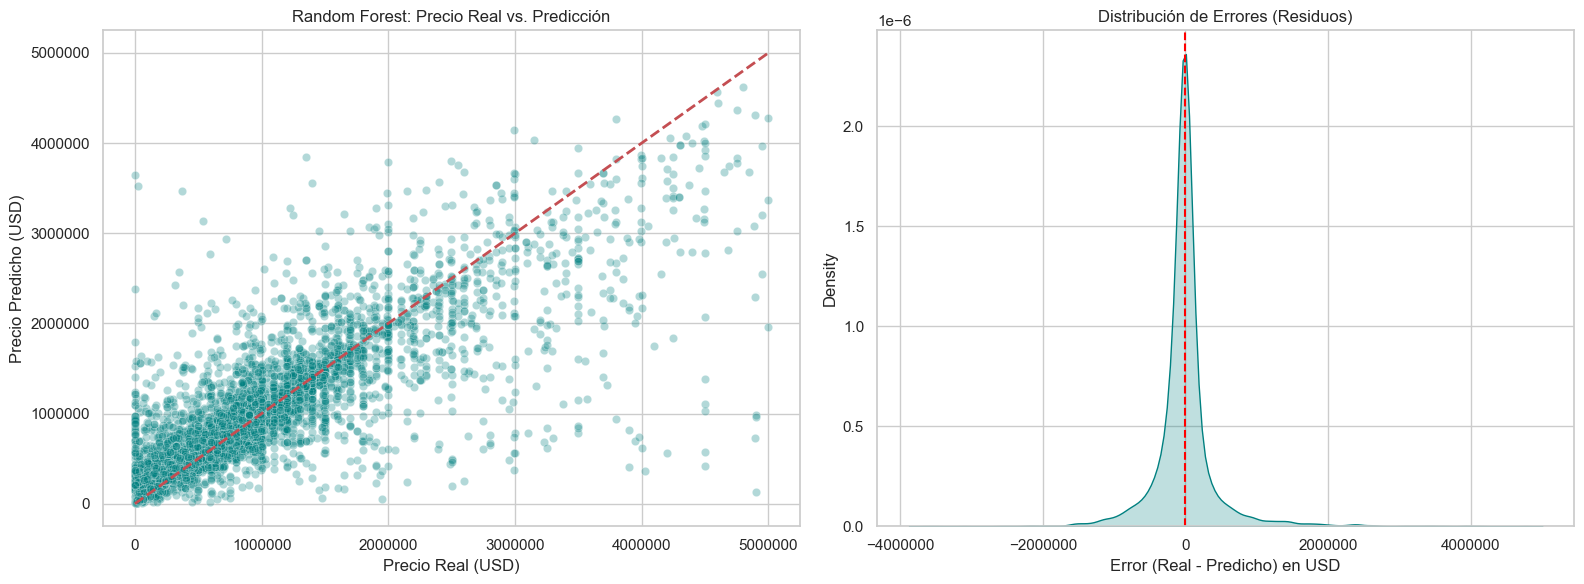

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Real vs Predicho (Random Forest)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.3, color='teal', ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Random Forest: Precio Real vs. Predicción')
axes[0].set_xlabel('Precio Real (USD)')
axes[0].set_ylabel('Precio Predicho (USD)')
axes[0].ticklabel_format(style='plain', axis='both')

# Gráfico 2: Densidad de Residuos
residuos_rf = y_test - y_pred_rf
sns.kdeplot(residuos_rf, fill=True, color='teal', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de Errores (Residuos)')
axes[1].set_xlabel('Error (Real - Predicho) en USD')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

El análisis gráfico de las predicciones del modelo **Random Forest** nos permite entender no solo *cuánto* se equivoca el algoritmo en promedio, sino *cómo* y *dónde* comete esos errores:

1. **Precio Real vs. Predicción (Izquierda):**
   * La línea diagonal punteada roja representa la "predicción perfecta" (donde el precio predicho es exactamente igual al precio real).
   * Se observa una alta densidad de puntos fuertemente apegados a la línea roja en el rango de propiedades hasta los **$1.5 a $2 millones de dólares**. Esto indica que el modelo es altamente preciso para el mercado estándar y medio.
   * Sin embargo, a medida que los precios reales superan los $2.5 millones, los puntos comienzan a dispersarse y a situarse mayoritariamente *por debajo* de la línea roja. Esto significa que el modelo tiende a **subestimar** el valor de las propiedades de lujo (predice un precio menor al real).

2. **Distribución de Errores o Residuos (Derecha):**
   * Este gráfico muestra la densidad matemática de la diferencia ($Precio Real - Precio Predicho$). La línea vertical punteada marca el error cero.
   * La altísima concentración de la campana alrededor del cero confirma que la gran mayoría de las tasaciones del modelo son acertadas y equilibradas.
   * La asimetría o "cola larga" hacia la derecha (valores positivos mayores a $1,000,000) confirma numéricamente lo observado en el gráfico anterior: cuando el modelo comete errores significativos, casi siempre es porque el valor real era muchísimo mayor al calculado.

**Conclusión de Negocio:**
El modelo está listo y es altamente confiable para automatizar la tasación del mercado general de California. La pérdida de precisión en el sector de alto lujo es un fenómeno esperado, ya que las mansiones adquieren su valor por factores intangibles o altamente subjetivos (vistas panorámicas exclusivas, diseño arquitectónico de autor, acabados premium o valor histórico) que no logran ser capturados por las métricas estándar de metros cuadrados o cantidad de habitaciones.

*5. Conclusión de la Evaluación*

El modelo **Random Forest** supera consistentemente a la Regresión Lineal en todas las métricas. Presenta un error promedio significativamente menor y un coeficiente de determinación (R2) superior, lo que confirma su capacidad para modelar la complejidad del mercado inmobiliario en California.